In [2]:
import uproot
import numpy as np

filename = "e_Ge_2MeV.root"

process_map = {
    2002: "ionization",
    2003: "Bremsstrahlung",
    2010: "multiple scattering",
    2012: "photoelectric effect",
    2013: "Compton scattering",
}

with uproot.open(filename) as f:
    tree = f["t"]   # replace with your tree name
    pro = tree["pro"].array(library="np")
    pdg = tree["pdg"].array(library="np")

mask = (pdg == 11) & (pro > 1500) & (pro < 3000)
pro_selected = pro[mask]

total = len(pro_selected)

print(f"Total selected steps = {total}")
for pid, pname in process_map.items():
    count = np.sum(pro_selected == pid)
    frac = count / total if total > 0 else 0
    print(f"{pname:25s}  PID={pid}  count={count:8d}  fraction={frac:.4f}")

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

In [5]:
import uproot
import awkward as ak
import numpy as np
import matplotlib.pyplot as plt
filename = "e_Ge_2MeV.root"

process_map = {
    2002: "ionization",
    2003: "Bremsstrahlung",
    2005: "annihilation",
    2010: "multiple scattering",
    2012: "photoelectric effect",
    2013: "Compton scattering",
}

with uproot.open(filename) as f:
    tree = f["t"]   # change if your tree name is different

    pro = tree["pro"].array()
    pdg = tree["pdg"].array()

# Flatten the step arrays
pro = ak.flatten(pro)
pdg = ak.flatten(pdg)

# Apply cuts
mask = (pdg == 11) & (pro > 1500) & (pro < 3000)

pro_selected = pro[mask]

total = len(pro_selected)

print("Total steps:", total)

for pid, name in process_map.items():
    count = np.sum(pro_selected == pid)
    fraction = count / total if total > 0 else 0
    print(f"{name:25s}  PID={pid}  fraction={fraction:.4f}")

Total steps: 946941
ionization                 PID=2002  fraction=0.2850
Bremsstrahlung             PID=2003  fraction=0.0243
annihilation               PID=2005  fraction=0.0000
multiple scattering        PID=2010  fraction=0.4627
photoelectric effect       PID=2012  fraction=0.2165
Compton scattering         PID=2013  fraction=0.0115


In [6]:
plt.figure(figsize=(11, 6.5))

for pname, yvals in fractions.items():
    plt.plot(energies, yvals, marker='o', markersize=8, linewidth=2, label=pname)

plt.xscale("log")
plt.xlabel("Electron energy (MeV)", fontsize=15)
plt.ylabel("Process fraction", fontsize=15)
plt.title("'pro' fractions vs energy (Ge)", fontsize=18)
plt.legend(fontsize=13, loc="center left", bbox_to_anchor=(1.0, 0.5))
plt.tick_params(axis='both', labelsize=13)
plt.grid(True, which='both', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

NameError: name 'fractions' is not defined

<Figure size 1100x650 with 0 Axes>

Total selected steps: 946941
ionization                PID=2002 count=269844 fraction=0.2850
Bremsstrahlung            PID=2003 count=23049 fraction=0.0243
annihilation              PID=2005 count=0 fraction=0.0000
multiple scattering       PID=2010 count=438108 fraction=0.4627
photoelectric effect      PID=2012 count=205046 fraction=0.2165
Compton scattering        PID=2013 count=10894 fraction=0.0115


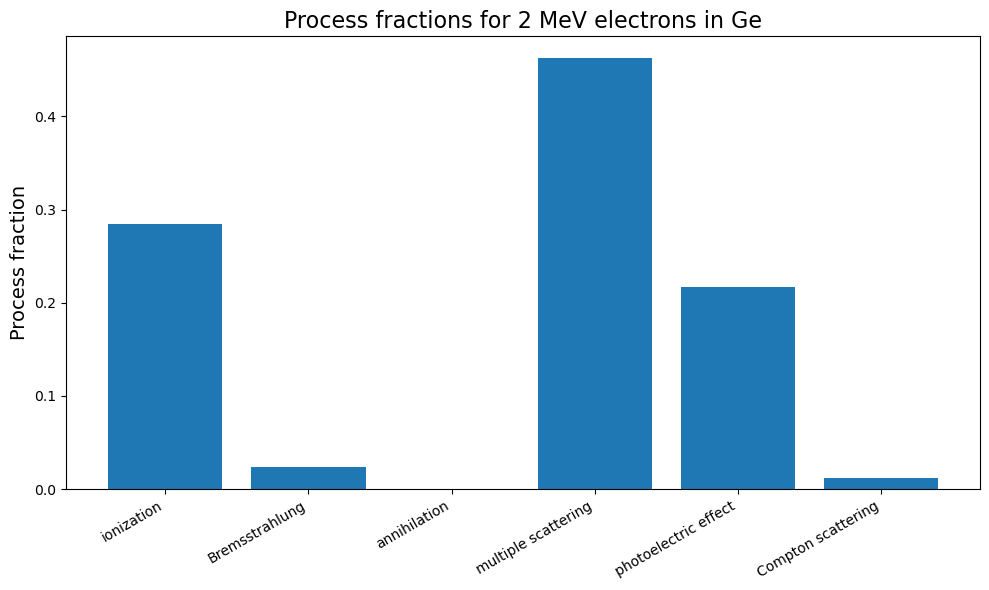

In [7]:
import uproot
import awkward as ak
import numpy as np
import matplotlib.pyplot as plt

filename = "e_Ge_2MeV.root"

process_map = {
    2002: "ionization",
    2003: "Bremsstrahlung",
    2005: "annihilation",
    2010: "multiple scattering",
    2012: "photoelectric effect",
    2013: "Compton scattering",
}

with uproot.open(filename) as f:
    tree = f["t"]   # your tree name

    pro = tree["pro"].array()
    pdg = tree["pdg"].array()

# Flatten jagged arrays
pro = ak.flatten(pro)
pdg = ak.flatten(pdg)

# Apply cuts
mask = (pdg == 11) & (pro > 1500) & (pro < 3000)
pro_selected = pro[mask]

total = len(pro_selected)
print("Total selected steps:", total)

labels = []
fractions = []

for pid, name in process_map.items():
    count = np.sum(pro_selected == pid)
    fraction = count / total if total > 0 else 0
    print(f"{name:25s} PID={pid} count={count} fraction={fraction:.4f}")
    
    labels.append(name)
    fractions.append(fraction)

# Plot bar chart
plt.figure(figsize=(10, 6))
plt.bar(labels, fractions)
plt.ylabel("Process fraction", fontsize=14)
plt.title("Process fractions for 2 MeV electrons in Ge", fontsize=16)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


Case: e- in Ge (2 MeV)
Total selected steps: 946941
ionization                PID=2002  count=  269844  fraction=0.2850
Bremsstrahlung            PID=2003  count=   23049  fraction=0.0243
annihilation              PID=2005  count=       0  fraction=0.0000
multiple scattering       PID=2010  count=  438108  fraction=0.4627
photoelectric effect      PID=2012  count=  205046  fraction=0.2165
Compton scattering        PID=2013  count=   10894  fraction=0.0115

Case: e- in Si (2 MeV)
Total selected steps: 519301
ionization                PID=2002  count=  157337  fraction=0.3030
Bremsstrahlung            PID=2003  count=   14695  fraction=0.0283
annihilation              PID=2005  count=       0  fraction=0.0000
multiple scattering       PID=2010  count=  288375  fraction=0.5553
photoelectric effect      PID=2012  count=   45695  fraction=0.0880
Compton scattering        PID=2013  count=   13199  fraction=0.0254

Case: e+ in Ge (2 MeV)
Total selected steps: 208999
ionization               

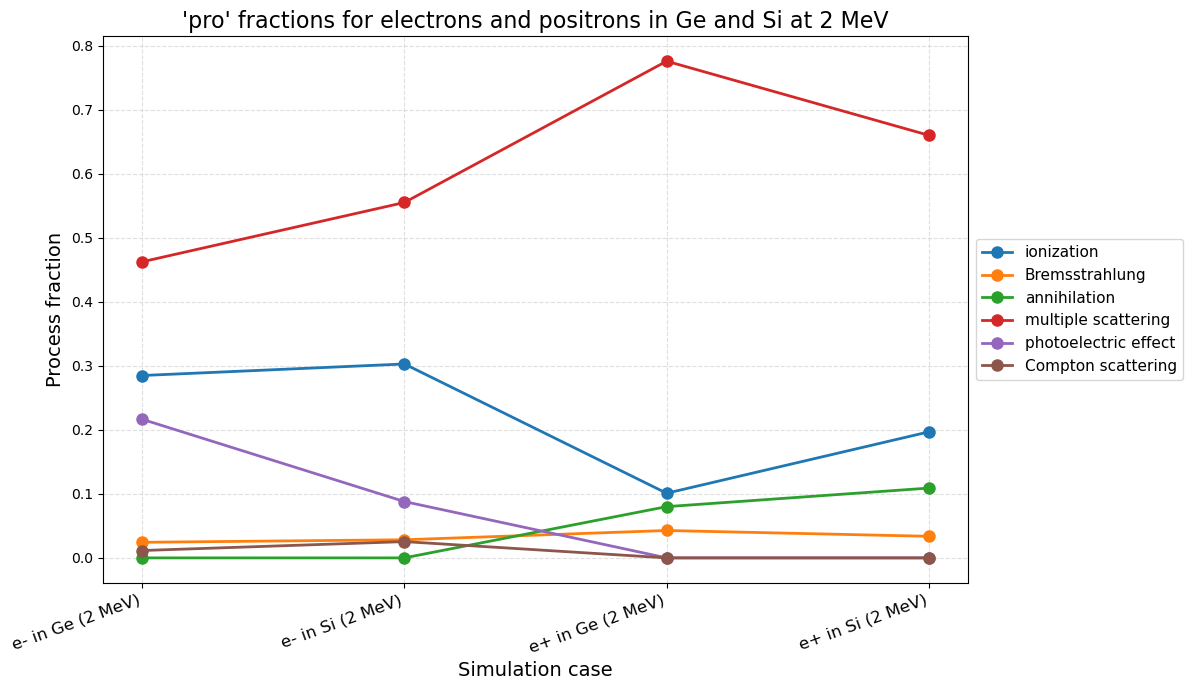

In [8]:
import uproot
import awkward as ak
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# 4 simulation files
# --------------------------------------------------
files = {
    "e- in Ge (2 MeV)": ("e_Ge_2MeV.root", 11),
    "e- in Si (2 MeV)": ("e_Si_2MeV.root", 11),
    "e+ in Ge (2 MeV)": ("e+_Ge_2MeV.root", -11),
    "e+ in Si (2 MeV)": ("e+_Si_2MeV.root", -11),
}

# --------------------------------------------------
# Process IDs
# --------------------------------------------------
process_map = {
    2002: "ionization",
    2003: "Bremsstrahlung",
    2005: "annihilation",
    2010: "multiple scattering",
    2012: "photoelectric effect",
    2013: "Compton scattering",
}

# --------------------------------------------------
# Store fractions
# --------------------------------------------------
cases = list(files.keys())
fractions = {name: [] for name in process_map.values()}

# --------------------------------------------------
# Loop over files
# --------------------------------------------------
for case_name, (filename, pdg_select) in files.items():
    with uproot.open(filename) as f:
        tree = f["t"]   # your tree name

        pro = tree["pro"].array()
        pdg = tree["pdg"].array()

    # Flatten jagged arrays
    pro = ak.flatten(pro)
    pdg = ak.flatten(pdg)

    # Apply cuts
    mask = (pdg == pdg_select) & (pro > 1500) & (pro < 3000)
    pro_selected = pro[mask]

    total = len(pro_selected)

    print(f"\nCase: {case_name}")
    print("Total selected steps:", total)

    for pid, pname in process_map.items():
        count = np.sum(pro_selected == pid)
        frac = count / total if total > 0 else 0.0
        fractions[pname].append(frac)

        print(f"{pname:25s} PID={pid}  count={count:8d}  fraction={frac:.4f}")

# --------------------------------------------------
# Plot
# --------------------------------------------------
x = np.arange(len(cases))

plt.figure(figsize=(12, 7))

for pname, yvals in fractions.items():
    plt.plot(x, yvals, marker='o', linewidth=2, markersize=8, label=pname)

plt.xticks(x, cases, rotation=20, ha='right', fontsize=12)
plt.ylabel("Process fraction", fontsize=14)
plt.xlabel("Simulation case", fontsize=14)
plt.title("'pro' fractions for electrons and positrons in Ge and Si at 2 MeV", fontsize=16)
plt.legend(fontsize=11, loc="center left", bbox_to_anchor=(1.0, 0.5))
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


File: e_Ge_2MeV.root
Energy = 2 MeV
Total selected steps: 946941
ionization                PID=2002  count=  269844  fraction=0.2850
Bremsstrahlung            PID=2003  count=   23049  fraction=0.0243
multiple scattering       PID=2010  count=  438108  fraction=0.4627
photoelectric effect      PID=2012  count=  205046  fraction=0.2165
Compton scattering        PID=2013  count=   10894  fraction=0.0115

File: e_Ge_100MeV.root
Energy = 100 MeV
Total selected steps: 20457502
ionization                PID=2002  count=10210970  fraction=0.4991
Bremsstrahlung            PID=2003  count=  628732  fraction=0.0307
multiple scattering       PID=2010  count=    8273  fraction=0.0004
photoelectric effect      PID=2012  count= 8295822  fraction=0.4055
Compton scattering        PID=2013  count= 1257768  fraction=0.0615

File: e_Si_2MeV.root
Energy = 2 MeV
Total selected steps: 519301
ionization                PID=2002  count=  157337  fraction=0.3030
Bremsstrahlung            PID=2003  count=   146

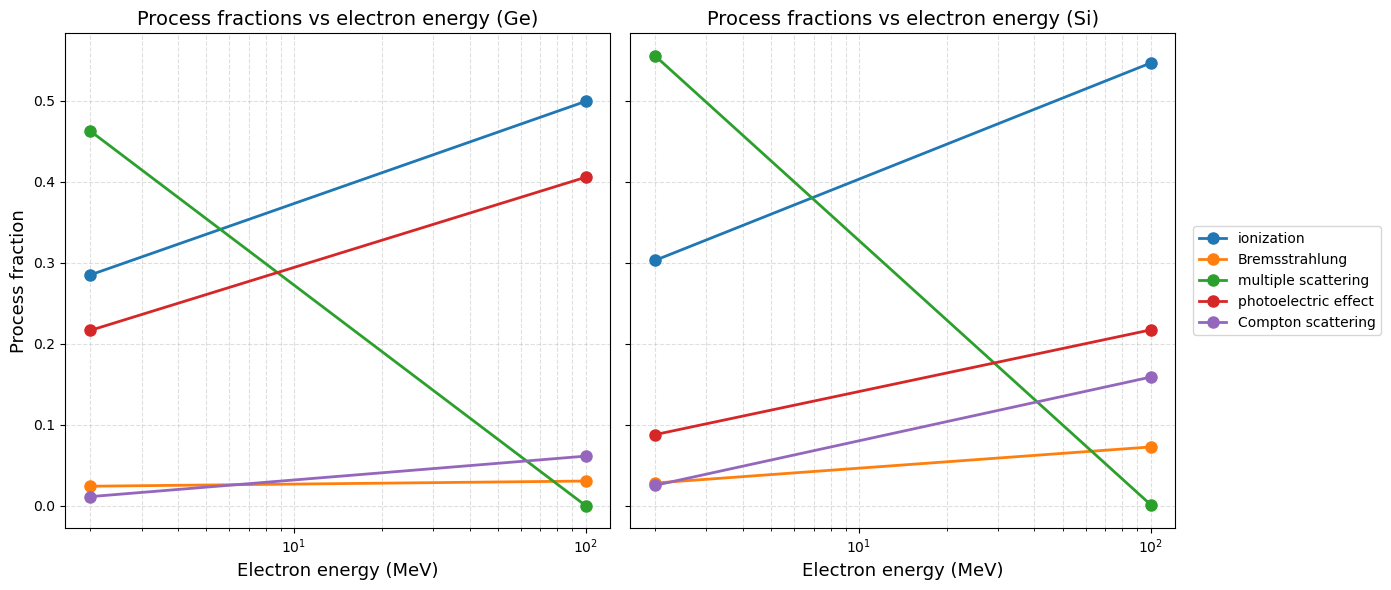

In [9]:
import uproot
import awkward as ak
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# ROOT files for electron case
# Change filenames here if needed
# --------------------------------------------------
files = {
    "Ge": {
        2: "e_Ge_2MeV.root",
        100: "e_Ge_100MeV.root",
    },
    "Si": {
        2: "e_Si_2MeV.root",
        100: "e_Si_100MeV.root",
    }
}

# --------------------------------------------------
# Process IDs
# --------------------------------------------------
process_map = {
    2002: "ionization",
    2003: "Bremsstrahlung",
    2010: "multiple scattering",
    2012: "photoelectric effect",
    2013: "Compton scattering",
}

# --------------------------------------------------
# Function to compute fractions for one material
# --------------------------------------------------
def get_process_fractions(file_dict, pdg_select=11):
    energies = sorted(file_dict.keys())
    fractions = {name: [] for name in process_map.values()}

    for energy in energies:
        filename = file_dict[energy]

        with uproot.open(filename) as f:
            tree = f["t"]   # change if your tree name is different

            pro = tree["pro"].array()
            pdg = tree["pdg"].array()

        # flatten jagged arrays
        pro = ak.flatten(pro)
        pdg = ak.flatten(pdg)

        # apply cuts
        mask = (pdg == pdg_select) & (pro > 1500) & (pro < 3000)
        pro_selected = pro[mask]

        total = len(pro_selected)

        print(f"\nFile: {filename}")
        print(f"Energy = {energy} MeV")
        print("Total selected steps:", total)

        for pid, pname in process_map.items():
            count = np.sum(pro_selected == pid)
            frac = count / total if total > 0 else 0.0
            fractions[pname].append(frac)

            print(f"{pname:25s} PID={pid}  count={count:8d}  fraction={frac:.4f}")

    return energies, fractions

# --------------------------------------------------
# Get fractions for Ge and Si
# --------------------------------------------------
energies_ge, fractions_ge = get_process_fractions(files["Ge"], pdg_select=11)
energies_si, fractions_si = get_process_fractions(files["Si"], pdg_select=11)

# --------------------------------------------------
# Plot
# --------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# -------- Germanium --------
for pname, yvals in fractions_ge.items():
    axes[0].plot(energies_ge, yvals, marker='o', linewidth=2, markersize=8, label=pname)

axes[0].set_xscale("log")
axes[0].set_xlabel("Electron energy (MeV)", fontsize=13)
axes[0].set_ylabel("Process fraction", fontsize=13)
axes[0].set_title("Process fractions vs electron energy (Ge)", fontsize=14)
axes[0].grid(True, which='both', linestyle='--', alpha=0.4)

# -------- Silicon --------
for pname, yvals in fractions_si.items():
    axes[1].plot(energies_si, yvals, marker='o', linewidth=2, markersize=8, label=pname)

axes[1].set_xscale("log")
axes[1].set_xlabel("Electron energy (MeV)", fontsize=13)
axes[1].set_title("Process fractions vs electron energy (Si)", fontsize=14)
axes[1].grid(True, which='both', linestyle='--', alpha=0.4)

# legend
axes[1].legend(fontsize=10, loc="center left", bbox_to_anchor=(1.02, 0.5))

plt.tight_layout()
plt.show()


File: e+_Ge_2MeV.root
Energy = 2 MeV
Total selected steps: 208999
ionization                PID=2002  count=   21110  fraction=0.1010
Bremsstrahlung            PID=2003  count=    8942  fraction=0.0428
annihilation              PID=2005  count=   16734  fraction=0.0801
multiple scattering       PID=2010  count=  162205  fraction=0.7761
photoelectric effect      PID=2012  count=       0  fraction=0.0000
Compton scattering        PID=2013  count=       0  fraction=0.0000

File: e+_Ge_100MeV.root
Energy = 100 MeV
Total selected steps: 840630
ionization                PID=2002  count=  253715  fraction=0.3018
Bremsstrahlung            PID=2003  count=  450488  fraction=0.5359
annihilation              PID=2005  count=   77912  fraction=0.0927
multiple scattering       PID=2010  count=     824  fraction=0.0010
photoelectric effect      PID=2012  count=       0  fraction=0.0000
Compton scattering        PID=2013  count=       0  fraction=0.0000

File: e+_Si_2MeV.root
Energy = 2 MeV
Total se

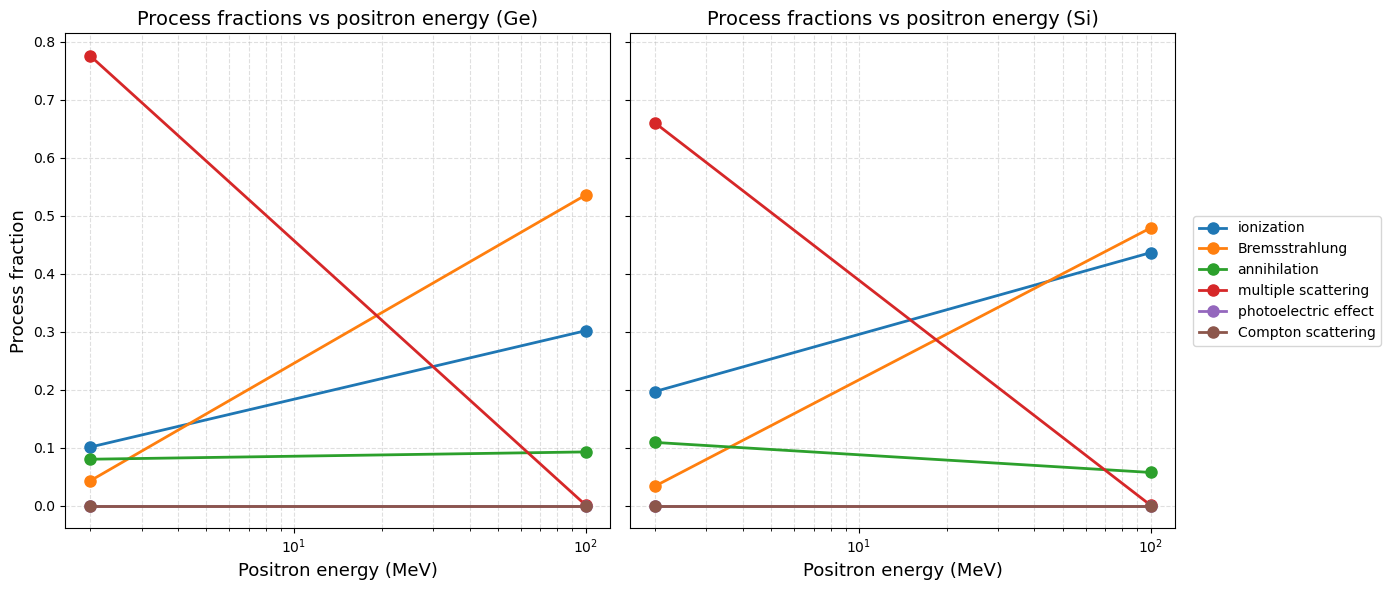

In [10]:
import uproot
import awkward as ak
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# ROOT files for positron case
# --------------------------------------------------
files = {
    "Ge": {
        2: "e+_Ge_2MeV.root",
        100: "e+_Ge_100MeV.root",
    },
    "Si": {
        2: "e+_Si_2MeV.root",
        100: "e+_Si_100MeV.root",
    }
}

# --------------------------------------------------
# Process IDs
# --------------------------------------------------
process_map = {
    2002: "ionization",
    2003: "Bremsstrahlung",
    2005: "annihilation",
    2010: "multiple scattering",
    2012: "photoelectric effect",
    2013: "Compton scattering",
}

# --------------------------------------------------
# Function to compute fractions for one material
# --------------------------------------------------
def get_process_fractions(file_dict, pdg_select=-11):
    energies = sorted(file_dict.keys())
    fractions = {name: [] for name in process_map.values()}

    for energy in energies:
        filename = file_dict[energy]

        with uproot.open(filename) as f:
            tree = f["t"]   # change if your tree name is different

            pro = tree["pro"].array()
            pdg = tree["pdg"].array()

        # Flatten jagged arrays
        pro = ak.flatten(pro)
        pdg = ak.flatten(pdg)

        # Apply cuts: positron + EM process range
        mask = (pdg == pdg_select) & (pro > 1500) & (pro < 3000)
        pro_selected = pro[mask]

        total = len(pro_selected)

        print(f"\nFile: {filename}")
        print(f"Energy = {energy} MeV")
        print("Total selected steps:", total)

        for pid, pname in process_map.items():
            count = np.sum(pro_selected == pid)
            frac = count / total if total > 0 else 0.0
            fractions[pname].append(frac)

            print(f"{pname:25s} PID={pid}  count={count:8d}  fraction={frac:.4f}")

    return energies, fractions

# --------------------------------------------------
# Get fractions for Ge and Si
# --------------------------------------------------
energies_ge, fractions_ge = get_process_fractions(files["Ge"], pdg_select=-11)
energies_si, fractions_si = get_process_fractions(files["Si"], pdg_select=-11)

# --------------------------------------------------
# Plot
# --------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# -------- Germanium --------
for pname, yvals in fractions_ge.items():
    axes[0].plot(energies_ge, yvals, marker='o', linewidth=2, markersize=8, label=pname)

axes[0].set_xscale("log")
axes[0].set_xlabel("Positron energy (MeV)", fontsize=13)
axes[0].set_ylabel("Process fraction", fontsize=13)
axes[0].set_title("Process fractions vs positron energy (Ge)", fontsize=14)
axes[0].grid(True, which='both', linestyle='--', alpha=0.4)

# -------- Silicon --------
for pname, yvals in fractions_si.items():
    axes[1].plot(energies_si, yvals, marker='o', linewidth=2, markersize=8, label=pname)

axes[1].set_xscale("log")
axes[1].set_xlabel("Positron energy (MeV)", fontsize=13)
axes[1].set_title("Process fractions vs positron energy (Si)", fontsize=14)
axes[1].grid(True, which='both', linestyle='--', alpha=0.4)

axes[1].legend(fontsize=10, loc="center left", bbox_to_anchor=(1.02, 0.5))

plt.tight_layout()
plt.show()